# Data preparation - default KO data - feature based on operon list

## load pq files and check data format

In [1]:
import pandas as pd

file_path = "/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet"

df = pd.read_parquet(file_path)

print("=" * 80)
print("Shape:")
print(df.shape)

print("\n" + "=" * 80)
print("Columns:")
for col in df.columns:
    print(col)

print("\n" + "=" * 80)
print("Data types:")
print(df.dtypes)

print("\n" + "=" * 80)
print("First 5 rows:")
print(df.head())

Shape:
(63482, 6)

Columns:
project
variant
label
time
listeners__mass__instantaneous_growth_rate
listeners__mass__dry_mass

Data types:
project                                        object
variant                                         int64
label                                          object
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
dtype: object

First 5 rows:
                      project  variant     label  time  \
0  gene_knockout_3_round_test        0  baseline   0.0   
1  gene_knockout_3_round_test        0  baseline  20.0   
2  gene_knockout_3_round_test        0  baseline  40.0   
3  gene_knockout_3_round_test        0  baseline  60.0   
4  gene_knockout_3_round_test        0  baseline  80.0   

   listeners__mass__instantaneous_growth_rate  listeners__mass__dry_mass  
0                                    0.000000                 266.478760  
1          

In [2]:
print("\n" + "=" * 80)
print("First 10 rows:") #read interval needs to be changed
print(df.head(20))


First 10 rows:
                       project  variant     label   time  \
0   gene_knockout_3_round_test        0  baseline    0.0   
1   gene_knockout_3_round_test        0  baseline   20.0   
2   gene_knockout_3_round_test        0  baseline   40.0   
3   gene_knockout_3_round_test        0  baseline   60.0   
4   gene_knockout_3_round_test        0  baseline   80.0   
5   gene_knockout_3_round_test        0  baseline  100.0   
6   gene_knockout_3_round_test        0  baseline  120.0   
7   gene_knockout_3_round_test        0  baseline  140.0   
8   gene_knockout_3_round_test        0  baseline  160.0   
9   gene_knockout_3_round_test        0  baseline  180.0   
10  gene_knockout_3_round_test        0  baseline  200.0   
11  gene_knockout_3_round_test        0  baseline  220.0   
12  gene_knockout_3_round_test        0  baseline  240.0   
13  gene_knockout_3_round_test        0  baseline  260.0   
14  gene_knockout_3_round_test        0  baseline  280.0   
15  gene_knockout_3_roun

## Operon-level training data construction

### Double-check total unique operon ids

In [3]:
import pandas as pd

file_path = "/user/home/il22158/work/vEcoli/reading/imported/inferred_operons_from_TUs.csv"

df = pd.read_csv(file_path)

# count unique operon IDs (from conversion step)
unique_operon = df["operon_ids"].nunique()

print("Unique operon IDs:", unique_operon)

Unique operon IDs: 334


### Training data construction

In [4]:
import pandas as pd

# ----------------------------
# Paths
# ----------------------------
summary_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary.csv"
classification_file = "/user/home/il22158/work/vEcoli/surrogate/operon_classification.csv"
operon_map_file = "/user/home/il22158/work/vEcoli/reading/imported/inferred_operons_from_TUs.csv"

output_file = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv"

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(summary_file, engine="python")
class_df = pd.read_csv(classification_file)
operon_df = pd.read_csv(operon_map_file)

# ----------------------------
# TU -> operon mapping from the cited operon table
# ----------------------------
tu_to_operon = {}
for _, row in operon_df.iterrows():
    operon_id = pd.to_numeric(row["operon_ids"], errors="coerce")
    if pd.isna(operon_id):
        continue
    operon_id = int(operon_id)
    tu_ids = [tu.strip() for tu in str(row["tu_ids"]).split(";") if tu.strip()]
    for tu_id in tu_ids:
        tu_to_operon[tu_id] = operon_id

# ----------------------------
# Gene -> TU bridge, then TU -> operon
# ----------------------------
gene_to_tu = dict(zip(class_df["id"], class_df["tu_id"]))
if "symbol" in class_df.columns:
    gene_to_tu.update(dict(zip(class_df["symbol"], class_df["tu_id"])))

# ----------------------------
# Convert labels to numeric operon ids
# ----------------------------
def convert_to_operon(val):
    if pd.isna(val):
        return pd.NA

    val = str(val).strip()
    if not val or val == "baseline":
        return pd.NA

    direct_operon = tu_to_operon.get(val)
    if direct_operon is not None:
        return direct_operon

    tu_id = gene_to_tu.get(val)
    if tu_id is not None:
        return tu_to_operon.get(str(tu_id).strip(), pd.NA)

    return pd.NA

# ----------------------------
# Apply conversion
# ----------------------------
df["operon_id"] = df["gene_knockout"].apply(convert_to_operon).astype("Int64")

# ----------------------------
# Diagnostics
# ----------------------------
missing = df[df["operon_id"].isna()]["gene_knockout"].unique()

print("Unmapped values:", len(missing))
print(missing[:20])
print("Unique operons:", df["operon_id"].nunique(dropna=True))

# ----------------------------
# Save
# ----------------------------
df.to_csv(output_file, index=False)

print("Saved:", output_file)

Unmapped values: 1
['baseline']
Unique operons: 334
Saved: /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv


In [5]:
"""Drop inaccurate columns (as they ignore TU-operon hierarchy): 
associated_gene_total_numbers, 
operon_has_additional_genes_not_in_rest_gene_to_test,
n_additional_genes_not_in_rest_gene_to_test	genes_not_in_rest_gene_to_test,	
in_rest_tu_ids_to_test,	
in_rest_genes_to_test,	
source_file.
"""
path = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv"
with pd.option_context('display.max_columns', None):
    df = pd.read_csv(f"{path}")
    print("Columns before drop:", df.columns.tolist())

    columns_to_drop = [
        "associated_gene_total_numbers",
        "operon_has_additional_genes_not_in_rest_gene_to_test",
        "n_additional_genes_not_in_rest_gene_to_test",
        "genes_not_in_rest_gene_to_test",
        "in_rest_tu_ids_to_test",
        "in_rest_genes_to_test",
        "source_file"
    ]

    df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

    print("Columns after drop:", df.columns.tolist())

    # Save the cleaned DataFrame
    df.to_csv(path, index=False)
    print(f"Cleaned DataFrame saved to: {path}")

Columns before drop: ['gene_knockout', 'knockout_id_type', 'variant', 'seed', 'project_name', 'max_generation', 's_pq', 'associated_genes', 'associated_gene_total_numbers', 'operon_has_additional_genes_not_in_rest_gene_to_test', 'n_additional_genes_not_in_rest_gene_to_test', 'genes_not_in_rest_gene_to_test', 'in_rest_tu_ids_to_test', 'in_rest_genes_to_test', 'source_file', 'operon_id']
Columns after drop: ['gene_knockout', 'knockout_id_type', 'variant', 'seed', 'project_name', 'max_generation', 's_pq', 'associated_genes', 'operon_id']
Cleaned DataFrame saved to: /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv


In [6]:
"""Operon-level training dataset construction"""

from pathlib import Path
import re
import numpy as np
import pandas as pd

# ============================
# PATHS
# ============================
BASE = Path("/user/home/il22158/work/vEcoli")
SURROGATE_DIR = BASE / "surrogate"
TRAIN_DIR = SURROGATE_DIR / "train_data"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_102trails_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed101_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_leftover_seed100_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.parquet",
    BASE / "reading/results/growth_rate/growth_rate_timeseries_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.parquet",
]

SUMMARY_FILES = [
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed11_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_TU_ID_rest_list_rerun12_seed10_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_leftover_seed100_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed101_all.csv",
    BASE / "reading/results/growth_rate/growth_rate_summary_gene_knockout_102trails_seed100_all.csv",
]

OPERON_SUMMARY_FILE = SURROGATE_DIR / "results/default_KO/gene_knockout_generation_summary_operon_selective.csv"
OPERON_MAP_FILE = BASE / "reading/imported/inferred_operons_from_TUs.csv"


# ============================
# HELPERS
# ============================
def infer_seed(path: Path) -> int:
    match = re.search(r"seed(\d+)", path.name)
    if not match:
        raise ValueError(f"No seed in {path}")
    return int(match.group(1))


def load_timeseries(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)

    required = {
        "project",
        "variant",
        "label",
        "time",
        "listeners__mass__instantaneous_growth_rate",
        "listeners__mass__dry_mass",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")
    df["listeners__mass__instantaneous_growth_rate"] = pd.to_numeric(
        df["listeners__mass__instantaneous_growth_rate"], errors="coerce"
    )
    df["listeners__mass__dry_mass"] = pd.to_numeric(df["listeners__mass__dry_mass"], errors="coerce")

    return df


def load_summary(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = {
        "project",
        "variant",
        "label",
        "mean_growth_rate",
        "median_growth_rate",
        "std_growth_rate",
        "max_growth_rate",
        "initial_dry_mass",
        "final_dry_mass",
        "max_dry_mass",
        "fold_change_mass",
        "duration_sec",
        "n_timepoints",
        "generations_used",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns {missing}")

    df = df.copy()
    df["source_file"] = path.name
    df["lineage_seed"] = infer_seed(path)

    df["project"] = df["project"].astype(str)
    df["variant"] = pd.to_numeric(df["variant"], errors="coerce").astype("Int64")
    df["label"] = df["label"].astype("string")

    for column in required - {"project", "variant", "label"}:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    return df


def load_operon_universe(path: Path) -> list[str]:
    operon_df = pd.read_csv(path)
    if "operon_ids" not in operon_df.columns:
        raise ValueError(f"{path} missing column 'operon_ids'")
    operon_ids = (
        pd.to_numeric(operon_df["operon_ids"], errors="coerce")
        .dropna()
        .astype(int)
        .astype(str)
        .sort_values()
        .unique()
        .tolist()
    )
    if not operon_ids:
        raise RuntimeError(f"No operon IDs found in {path}")
    return operon_ids


def extract_gene(label: object) -> object:
    if pd.isna(label):
        return pd.NA
    text = str(label).strip()
    if text == "baseline":
        return "baseline"
    match = re.search(r"KO:([^,]+)", text)
    if match:
        return match.group(1).strip()
    return text


# ============================
# LOAD DATA
# ============================
timeseries_df = pd.concat([load_timeseries(path) for path in TIMESERIES_FILES], ignore_index=True)
summary_df = pd.concat([load_summary(path) for path in SUMMARY_FILES], ignore_index=True)
operon_summary_df = pd.read_csv(OPERON_SUMMARY_FILE)
all_operon_ids = load_operon_universe(OPERON_MAP_FILE)

print("Operon universe size:", len(all_operon_ids))
assert len(all_operon_ids) == 334, "Operon reference is not 334"


# ============================
# MAP LABELS TO OPERONS
# ============================
operon_summary_df = operon_summary_df.copy()
operon_summary_df["operon_id"] = pd.to_numeric(operon_summary_df["operon_id"], errors="coerce").astype("Int64")
operon_summary_df["gene_knockout"] = operon_summary_df["gene_knockout"].astype("string")
label_to_operon = (
    operon_summary_df.dropna(subset=["gene_knockout", "operon_id"])
    .drop_duplicates(subset=["gene_knockout"])
    .set_index("gene_knockout")["operon_id"]
    .to_dict()
)

summary_df = summary_df.sort_values(["lineage_seed", "project", "variant", "label"]).reset_index(drop=True)
summary_df["gene_extracted"] = summary_df["label"].apply(extract_gene)


def to_operon(value: object):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if not text or text == "baseline":
        return pd.NA
    if text in label_to_operon:
        return label_to_operon[text]
    return label_to_operon.get(text.replace("[c]", ""), pd.NA)


summary_df["ko_operon_id"] = summary_df["gene_extracted"].apply(to_operon).astype("Int64")
summary_df["run_type"] = np.where(summary_df["label"].astype(str).eq("baseline"), "baseline", "KO")
summary_df["ko_target_id"] = np.where(
    summary_df["run_type"].eq("baseline"),
    "baseline",
    summary_df["ko_operon_id"].astype("string"),
)
summary_df["ko_operon_count"] = np.where(summary_df["run_type"].eq("baseline"), 0, 1)


# ============================
# DEBUG OUTPUT
# ============================
debug_csv = TRAIN_DIR / "operon_mapping_debug.csv"
summary_df.to_csv(debug_csv, index=False)

unmapped_count = summary_df["ko_operon_id"].isna().sum()
print("DEBUG CSV saved:", debug_csv)
print("Unmapped rows:", unmapped_count)


# ============================
# FEATURE SPACE
# ============================
operon_onehot = pd.get_dummies(summary_df["ko_operon_id"], dtype=np.int8)
operon_onehot = operon_onehot.reindex(columns=all_operon_ids, fill_value=0)
operon_onehot.columns = [f"operon_available__{c}" for c in operon_onehot.columns]
operon_available = (1 - operon_onehot).astype(np.int8)

print("Feature dimension:", operon_available.shape[1])
assert operon_available.shape[1] == 334, "Feature space is not 334 operon IDs"


# ============================
# TARGET VARIABLES
# ============================
summary_df["growth_next_h"] = summary_df["mean_growth_rate"].astype(float) * 3600.0
summary_df["current_growth_h"] = summary_df["growth_next_h"]
summary_df["current_dry_mass_g"] = summary_df["initial_dry_mass"].astype(float)
summary_df["sample_id"] = (
    summary_df["project"].astype(str)
    + "|v" + summary_df["variant"].astype(str)
    + "|s" + summary_df["lineage_seed"].astype(str)
    + "|" + summary_df["label"].astype(str)
)


# ============================
# FINAL DATASET
# ============================
training_data = pd.concat(
    [
        summary_df[
            [
                "sample_id",
                "source_file",
                "lineage_seed",
                "project",
                "variant",
                "label",
                "run_type",
                "gene_extracted",
                "ko_operon_id",
                "ko_target_id",
                "ko_operon_count",
                "mean_growth_rate",
                "median_growth_rate",
                "std_growth_rate",
                "max_growth_rate",
                "initial_dry_mass",
                "final_dry_mass",
                "max_dry_mass",
                "fold_change_mass",
                "duration_sec",
                "n_timepoints",
                "generations_used",
                "growth_next_h",
                "current_growth_h",
                "current_dry_mass_g",
            ]
        ].reset_index(drop=True),
        operon_available.reset_index(drop=True),
    ],
    axis=1,
)


# ============================
# SAVE OUTPUTS
# ============================
out_parquet = TRAIN_DIR / "operon_level_training_dataset.parquet"
out_csv = TRAIN_DIR / "operon_level_training_dataset.csv"
feature_list_path = TRAIN_DIR / "operon_feature_list.csv"

training_data.to_parquet(out_parquet, index=False)
training_data.to_csv(out_csv, index=False)
summary_df.to_csv(TRAIN_DIR / "operon_summary_debug.csv", index=False)
timeseries_df.to_parquet(TRAIN_DIR / "operon_timeseries.parquet", index=False)
pd.DataFrame({"feature_name": operon_available.columns}).to_csv(feature_list_path, index=False)


# ============================
# FINAL CHECKS
# ============================
print("\n==== FINAL REPORT ====")
print("Rows:", len(training_data))
print("Operon universe:", len(all_operon_ids))
print("Unmapped labels:", unmapped_count)
print("Feature dimension:", operon_available.shape[1])
print("Saved:", out_parquet)


Operon universe size: 334
DEBUG CSV saved: /user/home/il22158/work/vEcoli/surrogate/train_data/operon_mapping_debug.csv
Unmapped rows: 6
Feature dimension: 334

==== FINAL REPORT ====
Rows: 796
Operon universe: 334
Unmapped labels: 6
Feature dimension: 334
Saved: /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset.parquet


**Operon-Level Training Dataset Construction**

1. Function and Data Flow

This pipeline constructs a machine learning training dataset from WholeCell knockout simulations while representing perturbations at the operon level.

Workflow

1. Load the growth-rate time-series parquet files and the summary CSV files.
2. Combine them into unified time-series and summary datasets.
3. Parse simulation labels to identify baseline simulations and knockout simulations.
4. Use the imported operon table, `inferred_operons_from_TUs.csv`, to define the operon universe and map each TU label to a numeric operon ID.
5. Use `operon_classification.csv` only as a bridge from gene labels to TU labels when the summary file stores gene-style identifiers.
6. Generate a binary operon feature matrix where:

   * `1` = operon available
   * `0` = operon knocked out

7. Create the final training dataset by combining:

   * Simulation metadata
   * Growth and biomass summary statistics
   * Operon-level feature vectors

8. Save processed datasets and debugging outputs for downstream machine learning and validation.

---

2. Output Files

`operon_level_training_dataset.parquet`

Primary machine learning dataset in parquet format.

Contains:

* Simulation metadata
* Growth targets
* Knockout identifiers
* Numeric operon feature columns

`operon_level_training_dataset.csv`

CSV version of the training dataset for manual inspection and validation.

`operon_mapping_debug.csv`

Debugging file showing:

* Original simulation labels
* Extracted gene identifiers
* Assigned numeric operon identifiers

Useful for checking mapping accuracy and identifying unmapped entries.

`operon_summary_debug.csv`

Combined summary dataset after preprocessing and operon mapping.

`operon_timeseries.parquet`

Combined time-series dataset containing all simulation trajectories.

Useful for:

* Recomputing summary statistics
* DTW analyses
* Additional feature engineering

`operon_feature_list.csv`

List of all operon feature names used in the final training dataset.

---

3. Expected Quantities

After successful execution, the following values are expected:

| Quantity            | Expected Value |
| ------------------- | -------------- |
| Total training rows | 796            |
| Baseline rows       | 6              |
| Knockout rows       | 790            |
| Operon universe size | 334           |
| Operon feature count | 334           |

The operon feature space should always be defined by `inferred_operons_from_TUs.csv` and contain exactly 334 unique operon IDs.

### Raw aggragated growth rate data inspection

Total operon IDs: 335


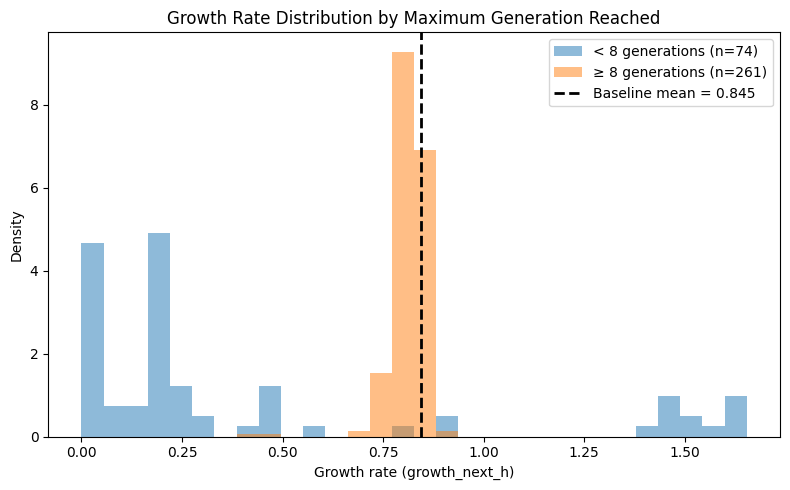

In [7]:
"""
Plot the growth rate distribution comparing TUs that reached at least 8 generations
vs those that stopped before 8 generations (including NaN max_generation cases,
which indicate simulations that did not reach the 8th generation).

Reference for max generation:
    "max_generation" in
    /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv

Reference for growth rate:
    "growth_next_h" in
    /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset.csv

Matching columns:
    "operon_id" in the max generation file corresponds to "ko_operon_id" in the training dataset.

Processing steps:
    - Growth rates are aggregated by averaging over lineage_seed for the first two seeds to obtain operon-level values.
    - Baseline growth rates are averaged across seeds to provide a single reference value.
    - max_generation NaN values are treated as "< 8" group.
    - The baseline samples are plotted alongside the knockout groups.
    - A vertical line is used to indicate the baseline mean growth rate.
"""
import pandas as pd
import matplotlib.pyplot as plt

# Out
out_dir = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO"

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset.csv"
)

# Operon-level max generation (KEEP NaNs)
gen_df = gen_df[["operon_id", "max_generation"]].drop_duplicates("operon_id")

# Growth preprocessing (unchanged)
baseline = train_df[train_df["run_type"] == "baseline"]

ko_df = train_df[train_df["run_type"] != "baseline"]

# keep only first two seeds per operon
ko_df = ko_df.sort_values(["ko_operon_id", "lineage_seed"])
ko_df = ko_df.groupby("ko_operon_id").head(2)

# average over those two seeds for each operon
ko_df = (
    ko_df.groupby("ko_operon_id", as_index=False)["growth_next_h"]
    .mean()
)

# baseline mean (average across also two seeds, as there are only seeds 100 and 101)
baseline_vals = baseline.groupby("lineage_seed", as_index=False)["growth_next_h"].mean()["growth_next_h"]
baseline_mean = baseline_vals.mean()

# merge (keep NaNs)
df = gen_df.merge(
    ko_df,
    left_on="operon_id",
    right_on="ko_operon_id",
    how="left"
)

print("Total operon IDs:", len(df))

# ---- FIX: NaNs belong to "< 8" group ----
stopped_before_8 = df.loc[
    (df["max_generation"] < 8) | (df["max_generation"].isna()),
    "growth_next_h"
]

reached_8_plus = df.loc[df["max_generation"] >= 8, "growth_next_h"]

# Shared bins
valid_vals = pd.concat([stopped_before_8, reached_8_plus, baseline_vals], ignore_index=True).dropna()
bins = 30
bin_range = (valid_vals.min(), valid_vals.max())

plt.figure(figsize=(8, 5))

plt.hist(stopped_before_8, bins=bins, range=bin_range, alpha=0.5, density=True,
         label=f"< 8 generations (n={len(stopped_before_8)})")

plt.hist(reached_8_plus, bins=bins, range=bin_range, alpha=0.5, density=True,
         label=f"≥ 8 generations (n={len(reached_8_plus)})")

# baseline reference line
plt.axvline(
    baseline_mean,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Baseline mean = {baseline_mean:.3f}"
)

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.savefig(f"{out_dir}/growth_rate_distribution_operon_level.png")
plt.show()

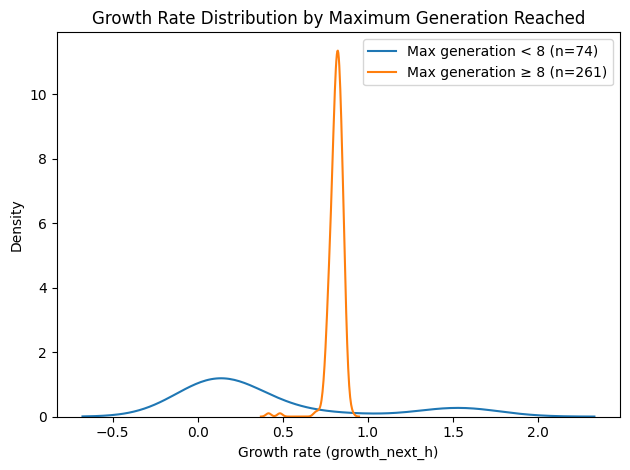

In [8]:
"""Alternative: KDE plot for smoother distribution comparison."""

import seaborn as sns

sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")
sns.kdeplot(reached_8_plus, label=f"Max generation ≥ 8 (n={len(reached_8_plus)})")

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.show()

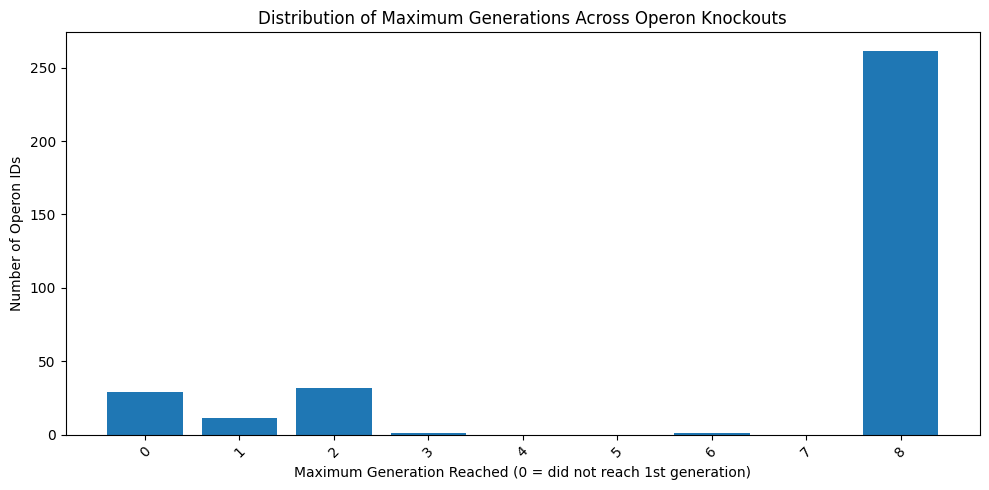

In [9]:
"""Inspect the max generation distribution across Operons only"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Count Operons at each maximum generation
gen_df["max_generation"] = gen_df["max_generation"].fillna(0)

gen_counts = (
    gen_df["max_generation"]
    .value_counts()
    .sort_index()
)

# Ensure 0 is included even if absent
all_gens = np.arange(0, gen_counts.index.max() + 1)
gen_counts = gen_counts.reindex(all_gens, fill_value=0)

# Plot
plt.figure(figsize=(10, 5))

plt.bar(gen_counts.index, gen_counts.values)

plt.xlabel("Maximum Generation Reached (0 = did not reach 1st generation)")
plt.ylabel("Number of Operon IDs")
plt.title("Distribution of Maximum Generations Across Operon Knockouts")

plt.xticks(gen_counts.index, rotation=45)
plt.tight_layout()
plt.show()

### Filtered training data - for the simulation failed to succeed to 8th generation take the growth rate as zero

In [14]:
"""Further filtering of training dataset: make the growth rate to zero for all samples where max_generation < 8. 
This is to reflect the fact that these lineages effectively failed to grow and should have zero growth rate, 
even if the measured growth_next_h is non-zero due to noise or short-term growth before collapse.
Save it to a new csv for data inspection."""
import pandas as pd

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset.csv"
)

# Operon-level max generation (keep NaN)
gen_df = gen_df[["operon_id", "max_generation"]].drop_duplicates("operon_id")

# Merge
df = train_df.merge(
    gen_df,
    left_on="ko_operon_id",
    right_on="operon_id",
    how="left"
)

# ---- IMPORTANT: separate baseline ----
baseline_mask = df["ko_operon_id"] == "baseline"

# Apply rule ONLY to KO samples
ko_mask = ~baseline_mask
filtered_mask = ko_mask & (df["max_generation"] < 8)
missing_mask = ko_mask & df["max_generation"].isna()
zeroed_mask = filtered_mask | missing_mask

df.loc[zeroed_mask, "growth_next_h"] = 0

# Clean helper column
df = df.drop(columns=["operon_id"])

# Save
output_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset_growth_filtered.csv"
df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print("Rows zeroed:", zeroed_mask.sum())
print("Rows still nonzero after filtering:", (zeroed_mask & (df["growth_next_h"] != 0)).sum())

Saved: /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset_growth_filtered.csv
Rows zeroed: 212
Rows still nonzero after filtering: 0


Total operon IDs: 335


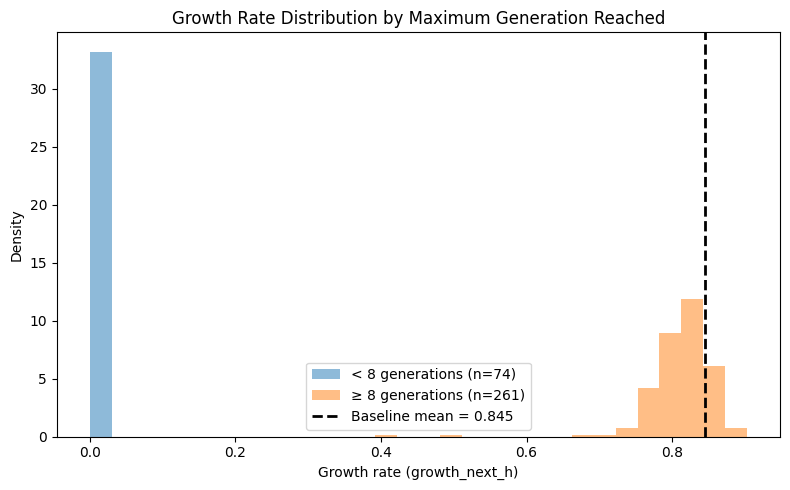

In [15]:
"""
Plot the growth rate distribution comparing TUs that reached at least 8 generations
vs those that stopped before 8 generations (including NaN max_generation cases,
which indicate simulations that did not reach the 8th generation).

Reference for max generation:
    "max_generation" in
    /user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv

Reference for growth rate:
    "growth_next_h" in
    /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset.csv

Matching columns:
    "operon_id" in the max generation file corresponds to "ko_operon_id" in the training dataset.

Processing steps:
    - Growth rates are aggregated by averaging over lineage_seed for the first two seeds to obtain operon-level values.
    - Baseline growth rates are averaged across seeds to provide a single reference value.
    - max_generation NaN values are treated as "< 8" group.
    - The baseline samples are plotted alongside the knockout groups.
    - A vertical line is used to indicate the baseline mean growth rate.
"""
import pandas as pd
import matplotlib.pyplot as plt

# Out
out_dir = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO"

# Load data
gen_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/results/default_KO/gene_knockout_generation_summary_operon_selective.csv"
)
train_df = pd.read_csv(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset_growth_filtered.csv"
)

# Operon-level max generation (KEEP NaNs)
gen_df = gen_df[["operon_id", "max_generation"]].drop_duplicates("operon_id")

# Growth preprocessing (unchanged)
baseline = train_df[train_df["run_type"] == "baseline"]

ko_df = train_df[train_df["run_type"] != "baseline"]

# keep only first two seeds per operon
ko_df = ko_df.sort_values(["ko_operon_id", "lineage_seed"])
ko_df = ko_df.groupby("ko_operon_id").head(2)

# average over those two seeds for each operon
ko_df = (
    ko_df.groupby("ko_operon_id", as_index=False)["growth_next_h"]
    .mean()
)

# baseline mean (average across also two seeds, as there are only seeds 100 and 101)
baseline_vals = baseline.groupby("lineage_seed", as_index=False)["growth_next_h"].mean()["growth_next_h"]
baseline_mean = baseline_vals.mean()

# merge (keep NaNs)
df = gen_df.merge(
    ko_df,
    left_on="operon_id",
    right_on="ko_operon_id",
    how="left"
)

print("Total operon IDs:", len(df))

# ---- FIX: NaNs belong to "< 8" group ----
stopped_before_8 = df.loc[
    (df["max_generation"] < 8) | (df["max_generation"].isna()),
    "growth_next_h"
]

reached_8_plus = df.loc[df["max_generation"] >= 8, "growth_next_h"]

# Shared bins
valid_vals = pd.concat([stopped_before_8, reached_8_plus, baseline_vals], ignore_index=True).dropna()
bins = 30
bin_range = (valid_vals.min(), valid_vals.max())

plt.figure(figsize=(8, 5))

plt.hist(stopped_before_8, bins=bins, range=bin_range, alpha=0.5, density=True,
         label=f"< 8 generations (n={len(stopped_before_8)})")

plt.hist(reached_8_plus, bins=bins, range=bin_range, alpha=0.5, density=True,
         label=f"≥ 8 generations (n={len(reached_8_plus)})")

# baseline reference line
plt.axvline(
    baseline_mean,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Baseline mean = {baseline_mean:.3f}"
)

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.savefig(f"{out_dir}/growth_rate_distribution_operon_level_filtered.png")
plt.show()

/tmp/ipykernel_1462005/413361357.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")


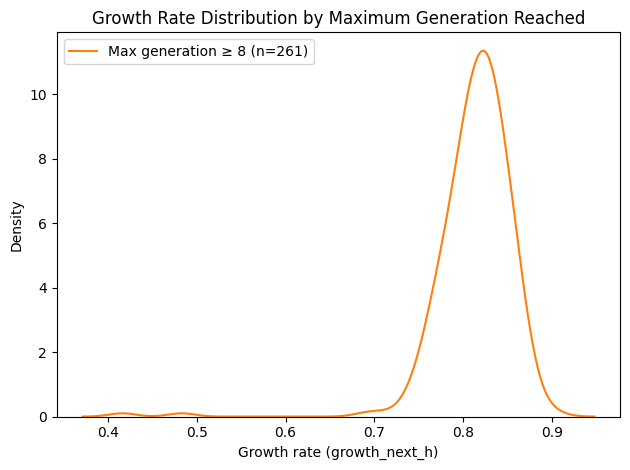

In [16]:
import seaborn as sns

sns.kdeplot(stopped_before_8, label=f"Max generation < 8 (n={len(stopped_before_8)})")
sns.kdeplot(reached_8_plus, label=f"Max generation ≥ 8 (n={len(reached_8_plus)})")

plt.xlabel("Growth rate (growth_next_h)")
plt.ylabel("Density")
plt.title("Growth Rate Distribution by Maximum Generation Reached")
plt.legend()
plt.tight_layout()
plt.show()

### Filtering training dataset - so only unique operon IDs and seeds are kept

In [18]:
import pandas as pd
from pathlib import Path

input_file = Path(
    "/user/home/il22158/work/vEcoli/surrogate/train_data/"
    "operon_level_training_dataset_growth_filtered.csv"
)

output_file = input_file.with_name(
    input_file.stem + "2.csv"
)

# Load dataset
df = pd.read_csv(input_file)

# Keep first occurrence of each operon ID + seed combination
df_trimmed = df.drop_duplicates(
    subset=["ko_operon_id", "lineage_seed"],
    keep="first"
)

# Save
df_trimmed.to_csv(output_file, index=False)

print(f"Original rows: {len(df)}")
print(f"Trimmed rows: {len(df_trimmed)}")
print(f"Saved to: {output_file}")

Original rows: 796
Trimmed rows: 698
Saved to: /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset_growth_filtered2.csv


# Baseline Linear Model - default KO data - operon level

## Data loading and inspect overall dimension

Training dataset: /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset_growth_filtered2.parquet

csv formated dataset: /user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset_growth_filtered2.csv

Training features: /user/home/il22158/work/vEcoli/surrogate/train_data/operon_feature_list.csv

In [2]:
import pandas as pd

feature_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/operon_feature_list.csv"
genotype_feature = pd.read_csv(feature_path)
print(f"Genotype feature count: {len(genotype_feature)}")
print(genotype_feature.head(20).to_string(index=False))

training_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/operon_level_training_dataset_growth_filtered2.csv"
training_df = pd.read_csv(training_path)
print(f"Training dataset rows: {len(training_df)}")
print(f"KO rows in training dataset: {int(training_df['run_type'].eq('KO').sum())}")
print(f"Baseline rows in training dataset: {int(training_df['run_type'].eq('baseline').sum())}")
print(training_df.head(20).to_string(index=False))

Genotype feature count: 334
          feature_name
 operon_available__100
operon_available__1017
 operon_available__102
operon_available__1028
operon_available__1033
 operon_available__107
operon_available__1071
operon_available__1074
operon_available__1089
operon_available__1103
operon_available__1123
operon_available__1130
operon_available__1149
operon_available__1170
operon_available__1185
operon_available__1186
operon_available__1206
operon_available__1212
operon_available__1219
operon_available__1220
Training dataset rows: 698
KO rows in training dataset: 696
Baseline rows in training dataset: 2
                                                    sample_id                                                              source_file  lineage_seed                             project  variant              label run_type gene_extracted  ko_operon_id ko_target_id  ko_operon_count  mean_growth_rate  median_growth_rate  std_growth_rate  max_growth_rate  initial_dry_mass  final_dry_mass  max_

## Inspect KOs with more than 2 seeds

In [7]:
from collections import Counter

ko_counts = training_df[training_df['run_type'].eq('KO')].groupby('ko_operon_id').size().sort_values(ascending=False)
overfull_kos = ko_counts[ko_counts > 2]

print(f"KOs with more than 2 seeds: {len(overfull_kos)}")
for ko_id, count in overfull_kos.items():
    ko_rows = training_df.loc[training_df['ko_operon_id'].eq(ko_id)]
    seeds = ko_rows['lineage_seed'].tolist()
    print(f"{ko_id} | count={count} | seeds={seeds}")

KOs with more than 2 seeds: 14
1292.0 | count=4 | seeds=[10, 11, 100, 101]
2305.0 | count=4 | seeds=[10, 11, 100, 101]
1664.0 | count=4 | seeds=[10, 11, 100, 101]
1760.0 | count=4 | seeds=[10, 11, 100, 101]
36.0 | count=4 | seeds=[10, 11, 100, 101]
1650.0 | count=4 | seeds=[10, 11, 100, 101]
2355.0 | count=4 | seeds=[10, 11, 100, 101]
1417.0 | count=4 | seeds=[10, 11, 100, 101]
2361.0 | count=4 | seeds=[10, 11, 100, 101]
2303.0 | count=4 | seeds=[10, 11, 100, 101]
37.0 | count=4 | seeds=[10, 11, 100, 101]
2297.0 | count=4 | seeds=[10, 11, 100, 101]
1809.0 | count=4 | seeds=[10, 11, 100, 101]
1827.0 | count=4 | seeds=[10, 11, 100, 101]


Selected KO: 1292
Training rows for this KO:
 ko_operon_id                             project  variant  lineage_seed run_type
       1292.0 gene_knockout_TU_ID_rest_list_rerun       85            10       KO
       1292.0 gene_knockout_TU_ID_rest_list_rerun       85            11       KO
       1292.0                gene_knockout_p_list       17           100       KO
       1292.0                gene_knockout_p_list       17           101       KO
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun | variant=85 | matched rows=531
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun | variant=85 | matched rows=511
seed=100 | project=gene_knockout_p_list | variant=17 | matched rows=1
seed=101 | project=gene_knockout_p_list | variant=17 | matched rows=1

Traces rendered: 4


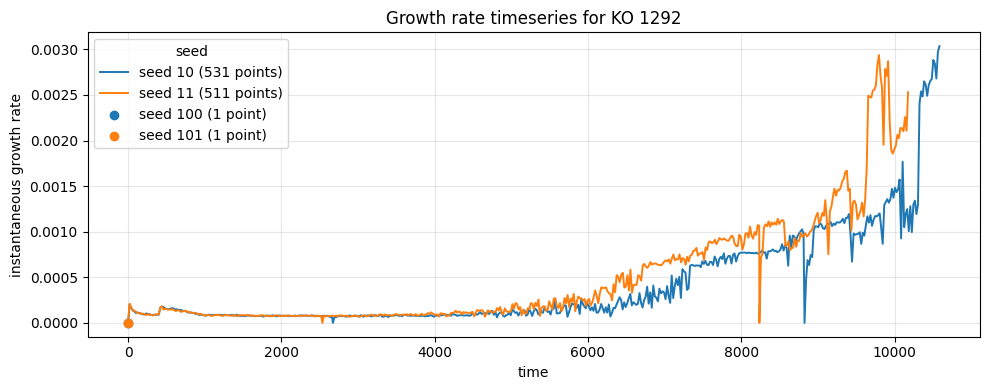

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'overfull_kos' not in globals():
    ko_counts = training_df[training_df['run_type'].eq('KO')].groupby('ko_operon_id').size().sort_values(ascending=False)
    overfull_kos = ko_counts[ko_counts > 2]

selected_ko = int(overfull_kos.index[0])
ko_rows = training_df.loc[training_df['ko_operon_id'].eq(selected_ko)].copy()
ko_rows = ko_rows.sort_values(['project', 'variant', 'lineage_seed'])

print(f"Selected KO: {selected_ko}")
print("Training rows for this KO:")
print(ko_rows[[c for c in ['ko_operon_id', 'project', 'variant', 'lineage_seed', 'run_type'] if c in ko_rows.columns]].to_string(index=False))

pq_path = '/user/home/il22158/work/vEcoli/surrogate/train_data/operon_timeseries.parquet'
pq = pd.read_parquet(pq_path)

project_col = 'project'
variant_col = 'variant'
seed_col = 'lineage_seed'
time_col = 'time'
growth_col = 'listeners__mass__instantaneous_growth_rate'

required = [project_col, variant_col, seed_col, time_col, growth_col]
missing = [column for column in required if column not in pq.columns]
if missing:
    raise KeyError(f"Missing required columns in parquet: {missing}")

plt.figure(figsize=(10, 4))
trace_count = 0

for _, row in ko_rows.iterrows():
    mask = (
        pq[project_col].eq(row[project_col])
        & pq[variant_col].eq(row[variant_col])
        & pq[seed_col].eq(row[seed_col])
    )
    matched = pq.loc[mask].sort_values(time_col).reset_index(drop=True)
    n_points = len(matched)

    print(
        f"seed={int(row[seed_col])} | project={row[project_col]} | variant={row[variant_col]} | matched rows={n_points}"
    )

    if matched.empty:
        print(f"Skipping seed {int(row[seed_col])}: no parquet rows matched")
        continue

    label = f"seed {int(row[seed_col])}"
    if n_points == 1:
        plt.scatter(
            matched[time_col],
            matched[growth_col],
            s=36,
            label=f"{label} (1 point)",
            zorder=3,
        )
    else:
        plt.plot(
            matched[time_col],
            matched[growth_col],
            linewidth=1.4,
            label=f"{label} ({n_points} points)",
        )

    trace_count += 1

print()
print(f"Traces rendered: {trace_count}")
if trace_count < len(ko_rows):
    print("Some seeds matched only a single point, so they will not appear as full curves.")

plt.title(f"Growth rate timeseries for KO {selected_ko}")
plt.xlabel('time')
plt.ylabel('instantaneous growth rate')
plt.grid(True, alpha=0.3)
plt.legend(title='seed')
plt.tight_layout()
plt.show()

Selected KO: 1292
Training rows for this KO:
 ko_operon_id                             project  variant  lineage_seed run_type
       1292.0 gene_knockout_TU_ID_rest_list_rerun       85            10       KO
       1292.0 gene_knockout_TU_ID_rest_list_rerun       85            11       KO
       1292.0                gene_knockout_p_list       17           100       KO
       1292.0                gene_knockout_p_list       17           101       KO
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun | variant=85 | matched rows=531
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun | variant=85 | matched rows=511
seed=100 | project=gene_knockout_p_list | variant=17 | matched rows=1
seed=101 | project=gene_knockout_p_list | variant=17 | matched rows=1

Traces rendered: 4


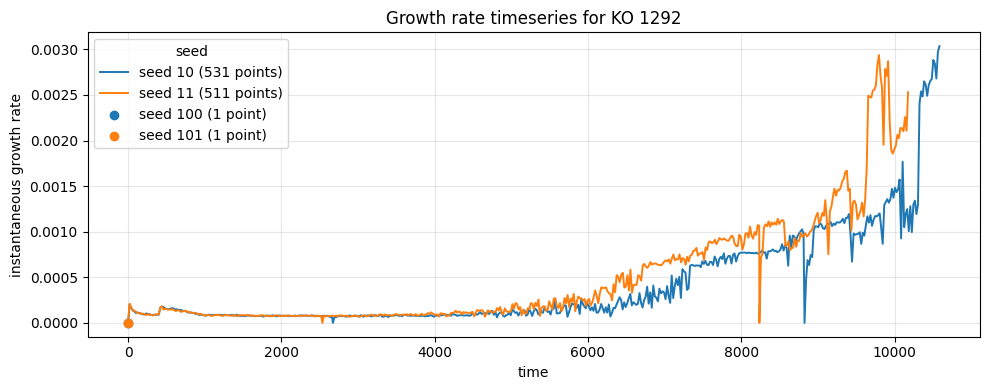

Selected KO: 2305
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
       2305.0           gene_knockout_3_round_test       11           100       KO
       2305.0           gene_knockout_3_round_test       11           101       KO
       2305.0 gene_knockout_TU_ID_rest_list_rerun2      122            10       KO
       2305.0 gene_knockout_TU_ID_rest_list_rerun2      122            11       KO
seed=100 | project=gene_knockout_3_round_test | variant=11 | matched rows=1419
seed=101 | project=gene_knockout_3_round_test | variant=11 | matched rows=1167
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=122 | matched rows=1212
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=122 | matched rows=1134

Traces rendered: 4


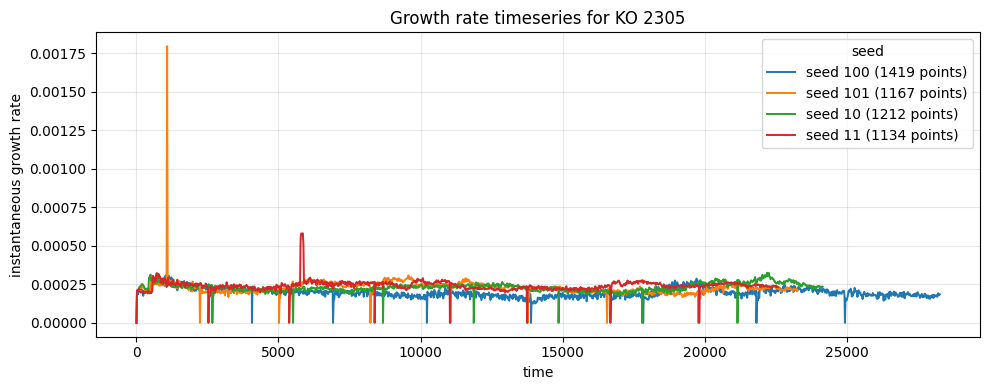

Selected KO: 1664
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
       1664.0           gene_knockout_3_round_test       34           100       KO
       1664.0           gene_knockout_3_round_test       34           101       KO
       1664.0 gene_knockout_TU_ID_rest_list_rerun2       18            10       KO
       1664.0 gene_knockout_TU_ID_rest_list_rerun2       18            11       KO
seed=100 | project=gene_knockout_3_round_test | variant=34 | matched rows=784
seed=101 | project=gene_knockout_3_round_test | variant=34 | matched rows=966
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=18 | matched rows=1276
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=18 | matched rows=1238

Traces rendered: 4


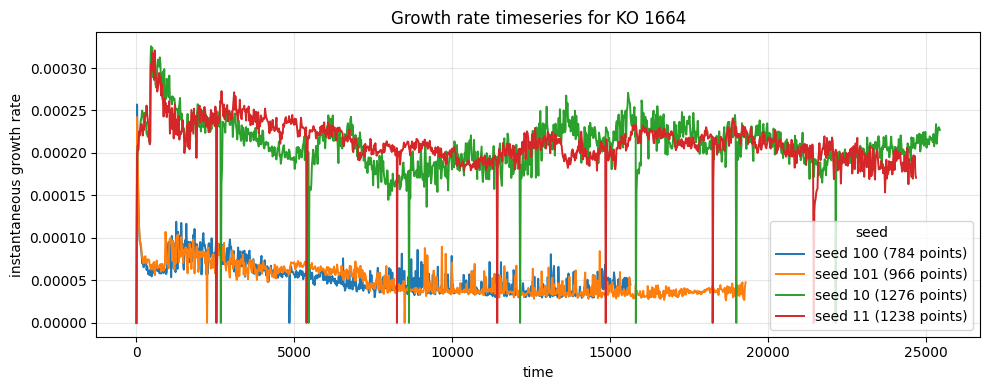

Selected KO: 1760
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
       1760.0           gene_knockout_3_round_test       47           100       KO
       1760.0           gene_knockout_3_round_test       47           101       KO
       1760.0 gene_knockout_TU_ID_rest_list_rerun2       39            10       KO
       1760.0 gene_knockout_TU_ID_rest_list_rerun2       39            11       KO
seed=100 | project=gene_knockout_3_round_test | variant=47 | matched rows=1280
seed=101 | project=gene_knockout_3_round_test | variant=47 | matched rows=1167
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=39 | matched rows=1217
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=39 | matched rows=1257

Traces rendered: 4


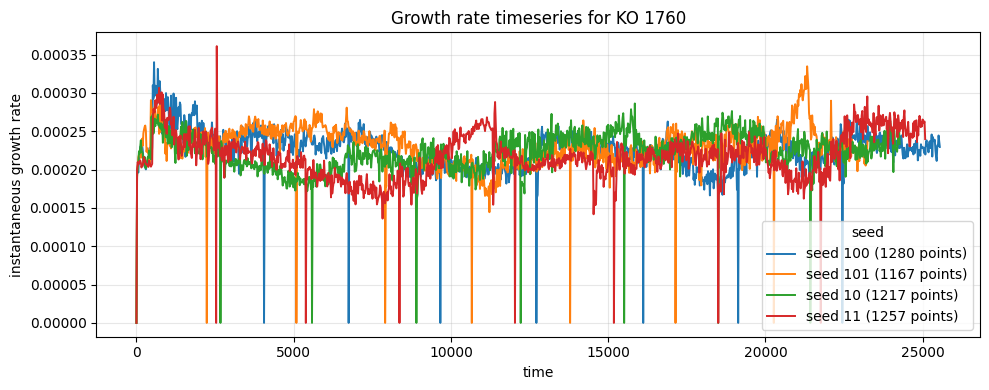

Selected KO: 36
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
         36.0           gene_knockout_3_round_test       27           100       KO
         36.0           gene_knockout_3_round_test       27           101       KO
         36.0 gene_knockout_TU_ID_rest_list_rerun2      102            10       KO
         36.0 gene_knockout_TU_ID_rest_list_rerun2      102            11       KO
seed=100 | project=gene_knockout_3_round_test | variant=27 | matched rows=1291
seed=101 | project=gene_knockout_3_round_test | variant=27 | matched rows=1115
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=102 | matched rows=1146
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=102 | matched rows=1159

Traces rendered: 4


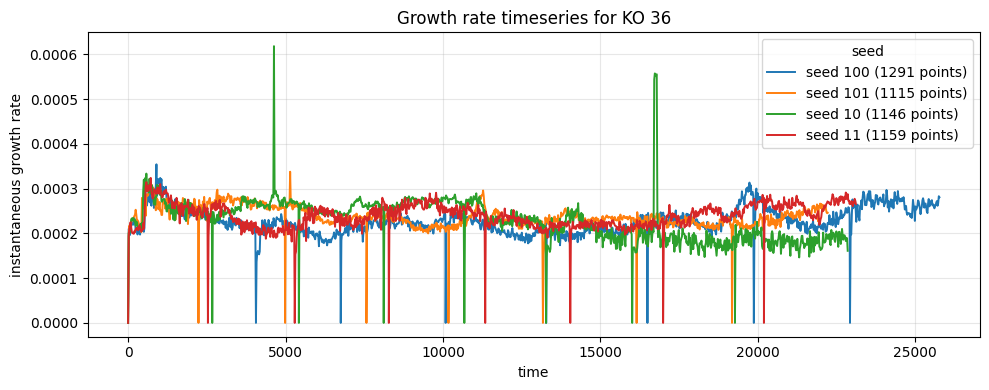

Selected KO: 1650
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
       1650.0 gene_knockout_TU_ID_rest_list_rerun2      110            10       KO
       1650.0 gene_knockout_TU_ID_rest_list_rerun2      110            11       KO
       1650.0                 gene_knockout_p_list       47           100       KO
       1650.0                 gene_knockout_p_list       47           101       KO
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=110 | matched rows=1080
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=110 | matched rows=1035
seed=100 | project=gene_knockout_p_list | variant=47 | matched rows=784
seed=101 | project=gene_knockout_p_list | variant=47 | matched rows=971

Traces rendered: 4


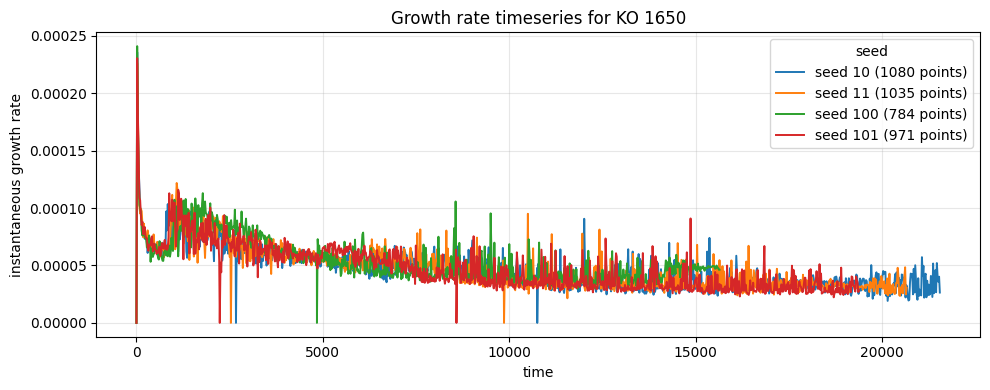

Selected KO: 2355
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
       2355.0           gene_knockout_3_round_test       10           100       KO
       2355.0           gene_knockout_3_round_test       10           101       KO
       2355.0 gene_knockout_TU_ID_rest_list_rerun2      132            10       KO
       2355.0 gene_knockout_TU_ID_rest_list_rerun2      132            11       KO
seed=100 | project=gene_knockout_3_round_test | variant=10 | matched rows=541
seed=101 | project=gene_knockout_3_round_test | variant=10 | matched rows=541
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=132 | matched rows=541
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=132 | matched rows=541

Traces rendered: 4


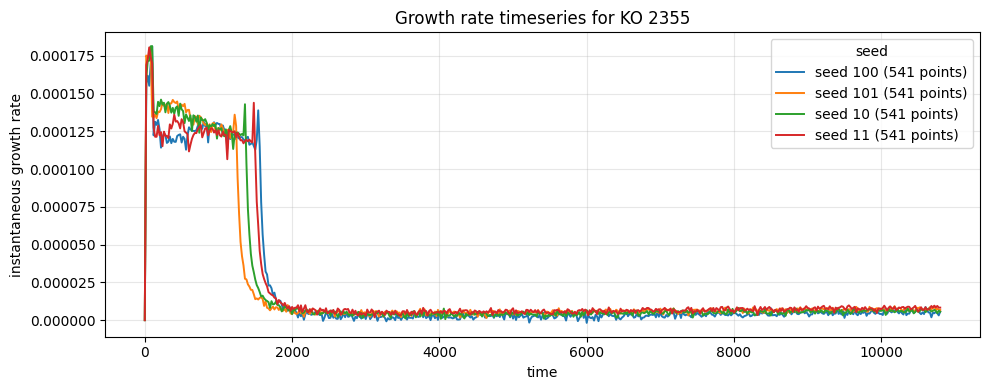

Selected KO: 1417
Training rows for this KO:
 ko_operon_id                             project  variant  lineage_seed run_type
       1417.0          gene_knockout_3_round_test        4           100       KO
       1417.0          gene_knockout_3_round_test        4           101       KO
       1417.0 gene_knockout_TU_ID_rest_list_rerun      129            10       KO
       1417.0 gene_knockout_TU_ID_rest_list_rerun      129            11       KO
seed=100 | project=gene_knockout_3_round_test | variant=4 | matched rows=1254
seed=101 | project=gene_knockout_3_round_test | variant=4 | matched rows=1103
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun | variant=129 | matched rows=1173
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun | variant=129 | matched rows=1243

Traces rendered: 4


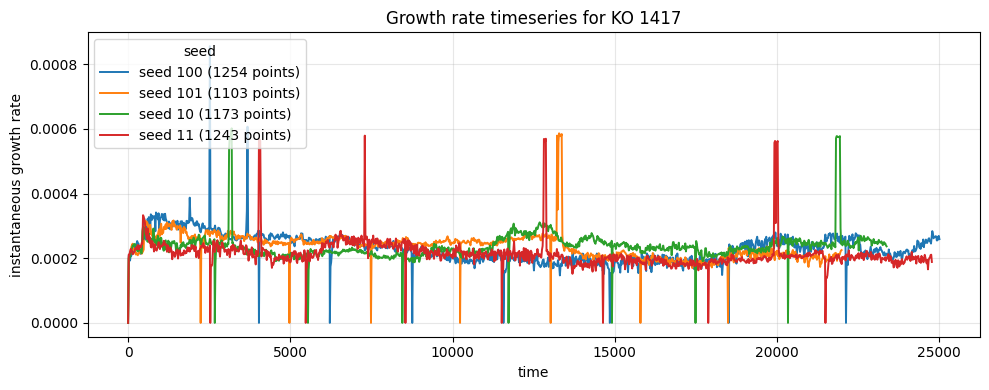

Selected KO: 2361
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
       2361.0           gene_knockout_3_round_test       29           100       KO
       2361.0           gene_knockout_3_round_test       29           101       KO
       2361.0 gene_knockout_TU_ID_rest_list_rerun2      133            10       KO
       2361.0 gene_knockout_TU_ID_rest_list_rerun2      133            11       KO
seed=100 | project=gene_knockout_3_round_test | variant=29 | matched rows=1285
seed=101 | project=gene_knockout_3_round_test | variant=29 | matched rows=1179
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=133 | matched rows=1192
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=133 | matched rows=1274

Traces rendered: 4


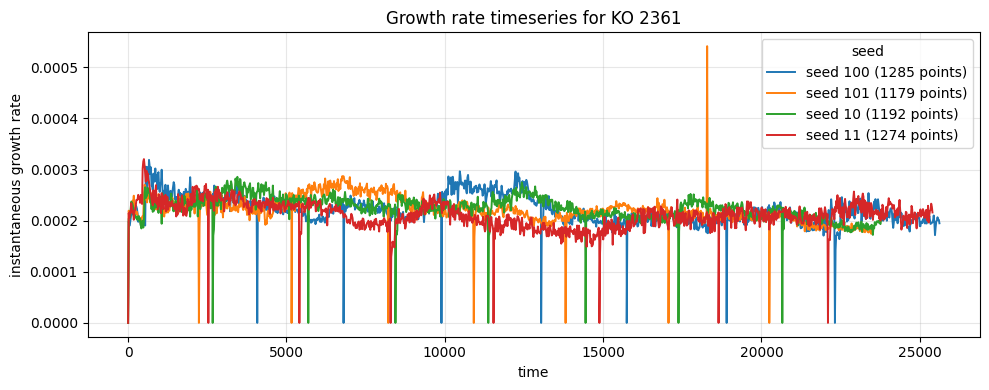

Selected KO: 2303
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
       2303.0           gene_knockout_3_round_test        1           100       KO
       2303.0           gene_knockout_3_round_test        1           101       KO
       2303.0 gene_knockout_TU_ID_rest_list_rerun2      120            10       KO
       2303.0 gene_knockout_TU_ID_rest_list_rerun2      120            11       KO
seed=100 | project=gene_knockout_3_round_test | variant=1 | matched rows=1235
seed=101 | project=gene_knockout_3_round_test | variant=1 | matched rows=1132
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=120 | matched rows=1218
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=120 | matched rows=1265

Traces rendered: 4


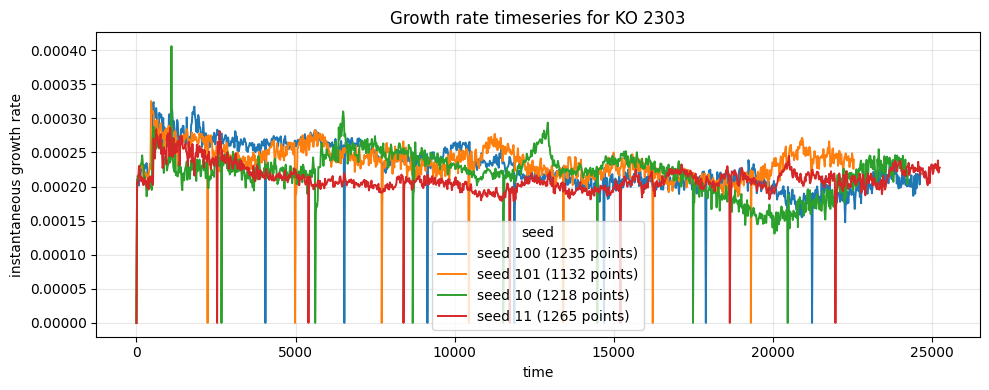

Selected KO: 37
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
         37.0 gene_knockout_TU_ID_rest_list_rerun2        1            10       KO
         37.0 gene_knockout_TU_ID_rest_list_rerun2        1            11       KO
         37.0                 gene_knockout_p_list       26           100       KO
         37.0                 gene_knockout_p_list       26           101       KO
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=1 | matched rows=1320
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=1 | matched rows=1179
seed=100 | project=gene_knockout_p_list | variant=26 | matched rows=1
seed=101 | project=gene_knockout_p_list | variant=26 | matched rows=1

Traces rendered: 4


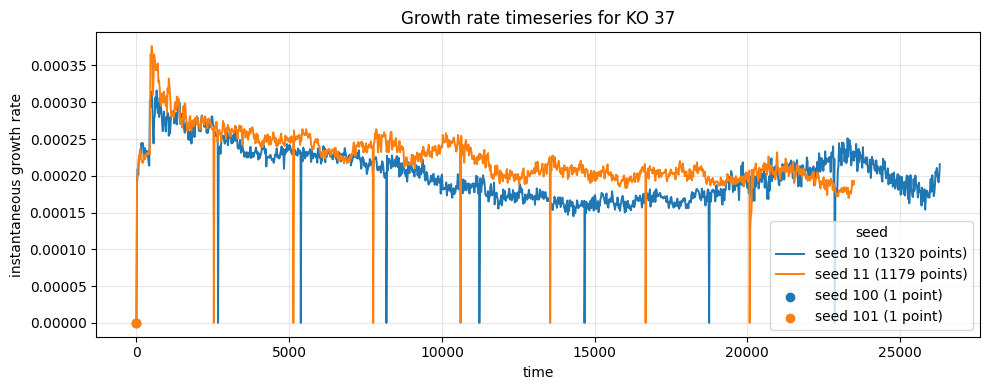

Selected KO: 2297
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
       2297.0           gene_knockout_3_round_test       18           100       KO
       2297.0           gene_knockout_3_round_test       18           101       KO
       2297.0 gene_knockout_TU_ID_rest_list_rerun2      115            10       KO
       2297.0 gene_knockout_TU_ID_rest_list_rerun2      115            11       KO
seed=100 | project=gene_knockout_3_round_test | variant=18 | matched rows=1226
seed=101 | project=gene_knockout_3_round_test | variant=18 | matched rows=1162
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=115 | matched rows=1182
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=115 | matched rows=1301

Traces rendered: 4


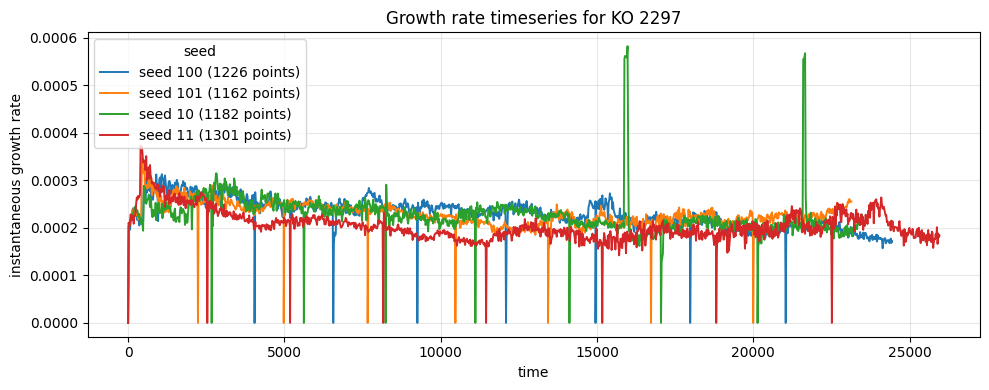

Selected KO: 1809
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
       1809.0 gene_knockout_TU_ID_rest_list_rerun2       55            10       KO
       1809.0 gene_knockout_TU_ID_rest_list_rerun2       55            11       KO
       1809.0                 gene_knockout_p_list        3           100       KO
       1809.0                 gene_knockout_p_list        3           101       KO
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=55 | matched rows=1196
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=55 | matched rows=1200
seed=100 | project=gene_knockout_p_list | variant=3 | matched rows=1
seed=101 | project=gene_knockout_p_list | variant=3 | matched rows=1

Traces rendered: 4


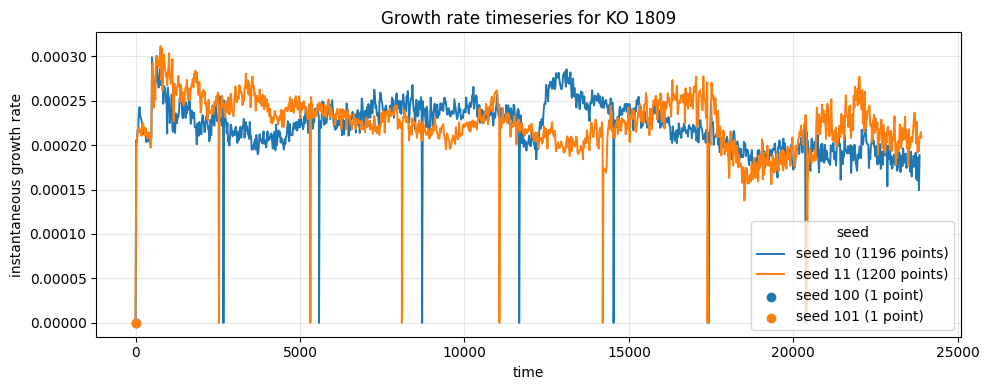

Selected KO: 1827
Training rows for this KO:
 ko_operon_id                              project  variant  lineage_seed run_type
       1827.0           gene_knockout_3_round_test       15           100       KO
       1827.0           gene_knockout_3_round_test       15           101       KO
       1827.0 gene_knockout_TU_ID_rest_list_rerun2       61            10       KO
       1827.0 gene_knockout_TU_ID_rest_list_rerun2       61            11       KO
seed=100 | project=gene_knockout_3_round_test | variant=15 | matched rows=1209
seed=101 | project=gene_knockout_3_round_test | variant=15 | matched rows=1145
seed=10 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=61 | matched rows=1226
seed=11 | project=gene_knockout_TU_ID_rest_list_rerun2 | variant=61 | matched rows=1203

Traces rendered: 4


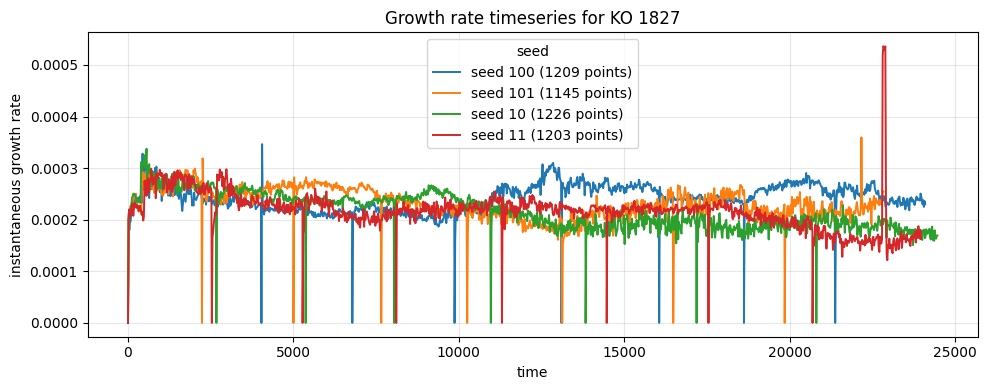

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Identify KO and raw timeseries data
if 'overfull_kos' not in globals():
    ko_counts = training_df[training_df['run_type'].eq('KO')].groupby('ko_operon_id').size().sort_values(ascending=False)
    overfull_kos = ko_counts[ko_counts > 2]

pq_path = '/user/home/il22158/work/vEcoli/surrogate/train_data/operon_timeseries.parquet'
pq = pd.read_parquet(pq_path)

# Create a function to plot growth timeseries for a given KO
def plot_growth_timeseries_for_ko(selected_ko: int, ko_rows: pd.DataFrame, pq: pd.DataFrame):
    project_col = 'project'
    variant_col = 'variant'
    seed_col = 'lineage_seed'
    time_col = 'time'
    growth_col = 'listeners__mass__instantaneous_growth_rate'

    required = [project_col, variant_col, seed_col, time_col, growth_col]
    missing = [column for column in required if column not in pq.columns]
    if missing:
        raise KeyError(f"Missing required columns in parquet: {missing}")

    plt.figure(figsize=(10, 4))
    trace_count = 0

    for _, row in ko_rows.iterrows():
        mask = (
            pq[project_col].eq(row[project_col])
            & pq[variant_col].eq(row[variant_col])
            & pq[seed_col].eq(row[seed_col])
        )
        matched = pq.loc[mask].sort_values(time_col).reset_index(drop=True)
        n_points = len(matched)

        print(
            f"seed={int(row[seed_col])} | project={row[project_col]} | variant={row[variant_col]} | matched rows={n_points}"
        )

        if matched.empty:
            print(f"Skipping seed {int(row[seed_col])}: no parquet rows matched")
            continue

        label = f"seed {int(row[seed_col])}"
        if n_points == 1:
            plt.scatter(
                matched[time_col],
                matched[growth_col],
                s=36,
                label=f"{label} (1 point)",
                zorder=3,
            )
        else:
            plt.plot(
                matched[time_col],
                matched[growth_col],
                linewidth=1.4,
                label=f"{label} ({n_points} points)",
            )

        trace_count += 1

    print()
    print(f"Traces rendered: {trace_count}")
    if trace_count < len(ko_rows):
        print("Some seeds matched only a single point, so they will not appear as full curves.")

    plt.title(f"Growth rate timeseries for KO {selected_ko}")
    plt.xlabel('time')
    plt.ylabel('instantaneous growth rate')
    plt.grid(True, alpha=0.3)
    plt.legend(title='seed')
    plt.tight_layout()
    plt.show()
    
# Apply the plotting function to all overfull KOs
for ko in overfull_kos.index:
    selected_ko = int(ko)
    ko_rows = training_df.loc[training_df['ko_operon_id'].eq(selected_ko)].copy()
    ko_rows = ko_rows.sort_values(['project', 'variant', 'lineage_seed'])
    print(f"Selected KO: {selected_ko}")
    print("Training rows for this KO:")
    print(ko_rows[[c for c in ['ko_operon_id', 'project', 'variant', 'lineage_seed', 'run_type'] if c in ko_rows.columns]].to_string(index=False))
    plot_growth_timeseries_for_ko(selected_ko, ko_rows, pq)


In [24]:
import pandas as pd

if 'overfull_kos' not in globals():
    ko_counts = (
        training_df[training_df['run_type'].eq('KO')]
        .groupby('ko_operon_id')
        .size()
        .sort_values(ascending=False)
    )
    overfull_kos = ko_counts[ko_counts > 2]

ko_df = training_df.loc[
    training_df['run_type'].eq('KO')
    & training_df['ko_operon_id'].isin(overfull_kos.index),
    ['ko_operon_id', 'project', 'variant', 'lineage_seed', 'label', 'mean_growth_rate']
].copy()

ko_df = ko_df.sort_values(['ko_operon_id', 'project', 'variant', 'lineage_seed']).reset_index(drop=True)

rows = []
for ko_id, group in ko_df.groupby('ko_operon_id', sort=False):
    base_row = group.iloc[0]
    base_mean = float(base_row['mean_growth_rate'])
    lower = base_mean * 0.8
    upper = base_mean * 1.2

    group = group.copy()
    group['reference_seed'] = int(base_row['lineage_seed'])
    group['reference_mean_growth_rate'] = base_mean
    group['lower_bound'] = lower
    group['upper_bound'] = upper
    group['within_band'] = group['mean_growth_rate'].between(lower, upper, inclusive='both')
    group['is_reference_row'] = group['lineage_seed'].eq(base_row['lineage_seed'])
    group['is_mismatch'] = ~group['within_band']

    rows.append(group)

check_df = pd.concat(rows, ignore_index=True)
check_df = check_df.sort_values(['ko_operon_id', 'project', 'variant', 'lineage_seed']).reset_index(drop=True)

mismatch_df = check_df.loc[check_df['is_mismatch']].copy()

print(f"Mismatched seeds using ±20% of the first seed mean_growth_rate: {len(mismatch_df)}")
if not mismatch_df.empty:
    print(
        mismatch_df[
            ['ko_operon_id', 'project', 'variant', 'lineage_seed', 'label']
        ].to_string(index=False)
    )
else:
    print('No mismatched seeds found with the ±20% criterion.')

print()
print("Reference rows are included in check_df and marked with is_reference_row = True.")
print("Saved dataframe name: check_df")

Mismatched seeds using ±20% of the first seed mean_growth_rate: 9
 ko_operon_id                              project  variant  lineage_seed            label
         37.0                 gene_knockout_p_list       26           100      KO: EG10890
         37.0                 gene_knockout_p_list       26           101      KO: EG10890
       1292.0                 gene_knockout_p_list       17           100      KO: EG10881
       1292.0                 gene_knockout_p_list       17           101      KO: EG10881
       1664.0 gene_knockout_TU_ID_rest_list_rerun2       18            10 KO: TU0-42569[c]
       1664.0 gene_knockout_TU_ID_rest_list_rerun2       18            11 KO: TU0-42569[c]
       1809.0                 gene_knockout_p_list        3           100      KO: EG10864
       1809.0                 gene_knockout_p_list        3           101      KO: EG10864
       2305.0 gene_knockout_TU_ID_rest_list_rerun2      122            11   KO: TU00117[c]

Reference rows are incl

In [26]:
out_dir = "/user/home/il22158/work/vEcoli/surrogate/results/default_KO"
mismatch_df.to_csv(f"{out_dir}/operon_seed_mean_mismatch_debug.csv", index=False)
check_df.to_csv(f"{out_dir}/operon_seed_mean_check_debug.csv", index=False)

Conclusion: 

seems that for TU KOs, it only knockout the associated TU; but for gene KOs, it knockout all TUs in the operons. Therefore the gene KOs show lower growth rate than TU ids, sometimes a qualitive change can occurs as well as the gene KOs can result in zero growth rate.

## Compare Essentiality for Gene KOs and TU KOs

In [5]:
import ast
import re
from pathlib import Path

import pandas as pd

BASE = Path("/user/home/il22158/work/vEcoli")
TRAIN_PATH = BASE / "surrogate/train_data/operon_level_training_dataset_growth_filtered.csv"
ESSENTIALITY_PATH = BASE / "reading/imported/table s7_data.csv"
CLASSIFICATION_PATH = BASE / "surrogate/operon_classification.csv"

train_df = pd.read_csv(TRAIN_PATH)
ess_df = pd.read_csv(ESSENTIALITY_PATH)
class_df = pd.read_csv(CLASSIFICATION_PATH)


GENE_PROJECTS = {
    "gene_knockout_3_round_test",
    "gene_knockout_leftover",
    "gene_knockout_p_list",
}
TU_PROJECTS = {
    "gene_knockout_TU_ID_rest_list_rerun",
    "gene_knockout_TU_ID_rest_list_rerun2",
}


def norm_rna(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    return re.sub(r"\[.*\]$", "", text)


def parse_rna_ids(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        parsed = value
    elif isinstance(value, str) and value.startswith("["):
        parsed = ast.literal_eval(value)
    else:
        parsed = [value]
    return [norm_rna(item) for item in parsed if pd.notna(item)]


ess_df = ess_df.copy()
ess_df["rna_norm"] = ess_df["RNA ID"].map(norm_rna)
ess_df = ess_df.drop_duplicates(subset=["rna_norm"])
ess_map = dict(zip(ess_df["rna_norm"], ess_df["Essentiality"]))

class_df = class_df.copy()
class_df["rna_list"] = class_df["rna_ids"].apply(parse_rna_ids)
class_df["tu_id_norm"] = class_df["tu_id"].map(norm_rna)

# Build bridges from the operon classification table.
gene_id_to_rna = {}
symbol_to_rna = {}
tu_to_rnas = {}
for _, row in class_df.iterrows():
    rna_list = row["rna_list"]
    if not rna_list:
        continue

    first_rna = rna_list[0]
    gene_id = str(row["id"]).strip() if pd.notna(row["id"]) else ""
    symbol = str(row["symbol"]).strip() if pd.notna(row["symbol"]) else ""
    tu_id = row["tu_id_norm"]

    if gene_id:
        gene_id_to_rna[gene_id] = first_rna
    if symbol:
        symbol_to_rna[symbol] = first_rna
    if pd.notna(tu_id):
        tu_to_rnas.setdefault(tu_id, []).extend(rna_list)

for tu_id, rna_list in tu_to_rnas.items():
    tu_to_rnas[tu_id] = sorted(set(rna_list))


train_df = train_df.copy()
train_df["label_core"] = train_df["label"].astype(str).str.replace(r"^KO:\s*", "", regex=True)
train_df["zero_growth"] = train_df["growth_next_h"].eq(0)

unexpected_projects = sorted(
    set(train_df["project"].astype(str).unique()) - GENE_PROJECTS - TU_PROJECTS
)
print("Unexpected projects:", unexpected_projects)


def to_rna_id(value):
    if pd.isna(value):
        return pd.NA
    key = norm_rna(value)
    if key in ess_map:
        return key
    if key in gene_id_to_rna:
        return gene_id_to_rna[key]
    if key in symbol_to_rna:
        return symbol_to_rna[key]
    return key


def compare_project_group(group_df, group_name, label_prefix, expand_tu=False):
    group_df = group_df.copy()
    group_df["project"] = group_df["project"].astype(str)

    if expand_tu:
        group_df["tu_id"] = group_df["label_core"].map(norm_rna)
        expanded_rows = []
        for _, row in group_df.iterrows():
            rna_list = tu_to_rnas.get(row["tu_id"], [])
            if not rna_list:
                expanded_rows.append(
                    {
                        "label": row["label"],
                        "project": row["project"],
                        "tu_id": row["tu_id"],
                        "rna_norm": pd.NA,
                        "growth_next_h": row["growth_next_h"],
                        "zero_growth": row["zero_growth"],
                        "essentiality": pd.NA,
                    }
                )
            else:
                for rna_norm in rna_list:
                    expanded_rows.append(
                        {
                            "label": row["label"],
                            "project": row["project"],
                            "tu_id": row["tu_id"],
                            "rna_norm": rna_norm,
                            "growth_next_h": row["growth_next_h"],
                            "zero_growth": row["zero_growth"],
                            "essentiality": ess_map.get(rna_norm, pd.NA),
                        }
                    )

        expanded_df = pd.DataFrame(expanded_rows)
        summary_df = expanded_df.groupby("label", as_index=False).agg(
            project=("project", "first"),
            tu_id=("tu_id", "first"),
            n_genes=("rna_norm", "nunique"),
            n_matched_genes=("essentiality", lambda s: s.notna().sum()),
            growth_next_h=("growth_next_h", "mean"),
            zero_growth=("zero_growth", "any"),
            essentiality=("essentiality", "max"),
        )
    else:
        group_df["rna_norm"] = group_df["gene_extracted"].fillna(group_df["label_core"]).map(to_rna_id)
        group_df["essentiality"] = group_df["rna_norm"].map(ess_map)
        summary_df = group_df.groupby("label", as_index=False).agg(
            project=("project", "first"),
            gene_rna_id=("rna_norm", "first"),
            growth_next_h=("growth_next_h", "mean"),
            zero_growth=("zero_growth", "any"),
            essentiality=("essentiality", "max"),
        )

    summary_df["match"] = summary_df["zero_growth"].eq(summary_df["essentiality"].eq(1))

    print()
    print(f"{group_name} comparison")
    print(f"Unique labels: {len(summary_df)}")
    print(f"Rows matched to Table S7: {summary_df['essentiality'].notna().sum()} / {len(summary_df)}")
    print(f"Agreement rate: {summary_df['match'].mean():.3f}")
    print(pd.crosstab(summary_df["zero_growth"], summary_df["essentiality"], dropna=False))

    if expand_tu:
        mismatch_cols = ["label", "project", "tu_id", "n_genes", "n_matched_genes", "growth_next_h", "essentiality", "zero_growth"]
    else:
        mismatch_cols = ["label", "project", "gene_rna_id", "growth_next_h", "essentiality", "zero_growth"]

    print(f"{group_name} mismatches (first 10)")
    print(
        summary_df.loc[~summary_df["match"], mismatch_cols]
        .head(10)
        .to_string(index=False)
    )

    return summary_df


# Gene KO comparison: project-sourced gene knockout simulations only.
gene_ko_df = train_df.loc[train_df["project"].isin(GENE_PROJECTS) & train_df["label_core"].str.startswith("EG", na=False)].copy()
gene_summary_df = compare_project_group(gene_ko_df, "Gene KO", "EG", expand_tu=False)


# TU KO comparison: project-sourced TU knockout simulations only.
# Table S7 is gene-based, so TU essentiality is treated as max(essentiality) over the TU genes.
tu_ko_df = train_df.loc[train_df["project"].isin(TU_PROJECTS) & train_df["label_core"].str.startswith("TU", na=False)].copy()
tu_summary_df = compare_project_group(tu_ko_df, "TU KO", "TU", expand_tu=True)


comparison_summary_df = pd.DataFrame(
    [
        {
            "comparison": "gene KO",
            "projects": ", ".join(sorted(GENE_PROJECTS)),
            "labels": len(gene_summary_df),
            "matched_to_s7": int(gene_summary_df["essentiality"].notna().sum()),
            "agreement_rate": float(gene_summary_df["match"].mean()),
        },
        {
            "comparison": "TU KO",
            "projects": ", ".join(sorted(TU_PROJECTS)),
            "labels": len(tu_summary_df),
            "matched_to_s7": int(tu_summary_df["essentiality"].notna().sum()),
            "agreement_rate": float(tu_summary_df["match"].mean()),
        },
    ]
)
print()
print(comparison_summary_df)


Unexpected projects: []

Gene KO comparison
Unique labels: 95
Rows matched to Table S7: 95 / 95
Agreement rate: 0.937
essentiality   0   1
zero_growth         
False         33   5
True           1  56
Gene KO mismatches (first 10)
      label                    project gene_rna_id  growth_next_h  essentiality  zero_growth
KO: EG10073 gene_knockout_3_round_test EG10073_RNA       0.187574             1        False
KO: EG10099 gene_knockout_3_round_test EG10099_RNA       0.849081             1        False
KO: EG10100 gene_knockout_3_round_test EG10100_RNA       0.849081             1        False
KO: EG10105 gene_knockout_3_round_test EG10105_RNA       0.849081             1        False
KO: EG10582 gene_knockout_3_round_test EG10582_RNA       0.794517             1        False
KO: EG10774 gene_knockout_3_round_test EG10774_RNA       0.000000             0         True

TU KO comparison
Unique labels: 285
Rows matched to Table S7: 285 / 285
Agreement rate: 0.884
essentiality    0   1


In [3]:
"""Save the two comparison summary tables."""
out_dir = "/user/home/il22158/work/vEcoli/surrogate/default_KO_vs_essentiality"
gene_summary_df.to_csv(f"{out_dir}/gene_ko_essentiality_comparison.csv", index=False)
tu_summary_df.to_csv(f"{out_dir}/tu_ko_essentiality_comparison.csv", index=False)

In [7]:
gene_mismatch_count = int((~gene_summary_df["match"]).sum())
tu_mismatch_count = int((~tu_summary_df["match"]).sum())
combined_mismatch_count = gene_mismatch_count + tu_mismatch_count

print("Gene KO mismatched outcomes:", gene_mismatch_count, "out of", len(gene_summary_df), "deviation rate: ", gene_mismatch_count / len(gene_summary_df) if len(gene_summary_df) > 0 else float('nan'))
print("TU KO mismatched outcomes:", tu_mismatch_count, "out of", len(tu_summary_df), "deviation rate: ", tu_mismatch_count / len(tu_summary_df) if len(tu_summary_df) > 0 else float('nan'))


Gene KO mismatched outcomes: 6 out of 95 deviation rate:  0.06315789473684211
TU KO mismatched outcomes: 33 out of 285 deviation rate:  0.11578947368421053


# Rerun operon on for rest of imported gene list

In [12]:
import pandas as pd
from pathlib import Path

base = Path("/user/home/il22158/work/vEcoli")
source_path = base / "reading/imported/Single_KO_RNA_names.txt"
training_path = base / "surrogate/train_data/operon_level_training_dataset_growth_filtered.csv"
output_path = base / "surrogate/rest_gene_rerun3.csv"

projects_to_exclude = {
    "gene_knockout_3_round_test",
    "gene_knockout_leftover",
    "gene_knockout_p_list",
}

source_genes = pd.read_csv(source_path, header=None, names=["gene_id"])
source_genes["gene_id"] = source_genes["gene_id"].astype(str).str.strip()
source_genes = source_genes.loc[source_genes["gene_id"].ne("")].drop_duplicates(subset=["gene_id"])

training_df = pd.read_csv(training_path)
excluded_genes = (
    training_df.loc[training_df["project"].isin(projects_to_exclude), "label"]
    .astype(str)
    .str.replace(r"^KO:\s*", "", regex=True)
    .str.replace(r"_RNA\[c\]$", "", regex=True)
    .str.replace(r"\[c\]$", "", regex=True)
    .loc[lambda series: series.ne("baseline")]
    .drop_duplicates()
)

rest_genes = source_genes.loc[~source_genes["gene_id"].isin(excluded_genes)].copy()
rest_genes.to_csv(output_path, index=False)

print("Source genes:", len(source_genes))
print("Excluded genes:", len(excluded_genes))
print("Rest genes:", len(rest_genes))
print("Saved:", output_path)
print(rest_genes.head(20).to_string(index=False))


Source genes: 462
Excluded genes: 105
Rest genes: 357
Saved: /user/home/il22158/work/vEcoli/surrogate/rest_gene_rerun3.csv
gene_id
EG10001
EG10004
EG10006
EG10007
EG10012
EG10017
EG10022
EG10023
EG10024
EG10025
EG10030
EG10031
EG10032
EG10034
EG10035
EG10039
EG10043
EG10045
EG10046
EG10048


In [13]:
output_path = base / "surrogate/rest_gene_rerun3.txt"

formatted_lines = [f'["{gene_id}"],' for gene_id in rest_genes["gene_id"]]
output_path.write_text("\n".join(formatted_lines) + "\n")

print("Rest genes:", len(rest_genes))
print("Saved:", output_path)
print("Preview:")
for line in formatted_lines[:20]:
    print(line)


Rest genes: 357
Saved: /user/home/il22158/work/vEcoli/surrogate/rest_gene_rerun3.txt
Preview:
["EG10001"],
["EG10004"],
["EG10006"],
["EG10007"],
["EG10012"],
["EG10017"],
["EG10022"],
["EG10023"],
["EG10024"],
["EG10025"],
["EG10030"],
["EG10031"],
["EG10032"],
["EG10034"],
["EG10035"],
["EG10039"],
["EG10043"],
["EG10045"],
["EG10046"],
["EG10048"],
